#Boosting Regression

In [17]:
import numpy as np
import pandas as pd
import xgboost
import math
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from __future__ import division
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score,mean_squared_error
from time import time
from sklearn.metrics import r2_score
import os
from sklearn.model_selection import train_test_split
#Machine Learning
from sklearn.ensemble import AdaBoostRegressor

In [18]:
data = pd.read_csv('score.csv')

In [19]:
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [20]:
print(len(data))
# Check the number of features in the data set
print(len(data.columns))
# Check the data types of each column
print(data.dtypes)

25
2
Hours     float64
Scores      int64
dtype: object


In [21]:
print(data.isnull().any().sum(), ' / ', len(data.columns))

0  /  2


In [22]:
print(data.isnull().any(axis=1).sum(), ' / ', len(data))

0  /  25


In [24]:
# As id and date columns are not important to predict price so we are discarding it for finding correlation
features = ['Hours'] # Assuming 'Hours' is the feature
target = 'Scores' # Assuming 'Scores' is the target

In [25]:
# Finding Correlation of price with other variables to see how many variables are strongly correlated with price
correlations = {}
for f in features:
    data_temp = data[[f,target]]
    x1 = data_temp[f].values
    x2 = data_temp[target].values
    key = f + ' vs ' + target
    correlations[key] = pearsonr(x1,x2)[0]

In [26]:
# Printing all the correlated features value with respect to price which is target variable
# Checking Corelation with price
data_correlations = pd.DataFrame(correlations, index=['Value']).T
data_correlations.loc[data_correlations['Value'].abs().sort_values(ascending=False).index]

,Value
Hours vs Scores,0.976191


<Axes: xlabel='Hours', ylabel='Scores'>

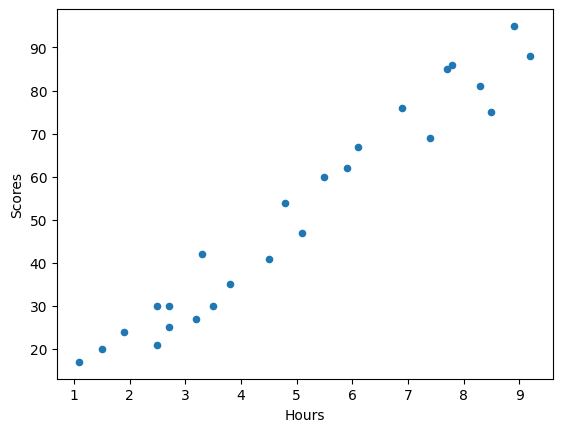

In [28]:
var = 'Hours'
data.plot.scatter(x=var, y='Scores')

Text(0.5, 1.0, 'Boxplot of Hours by Scores')

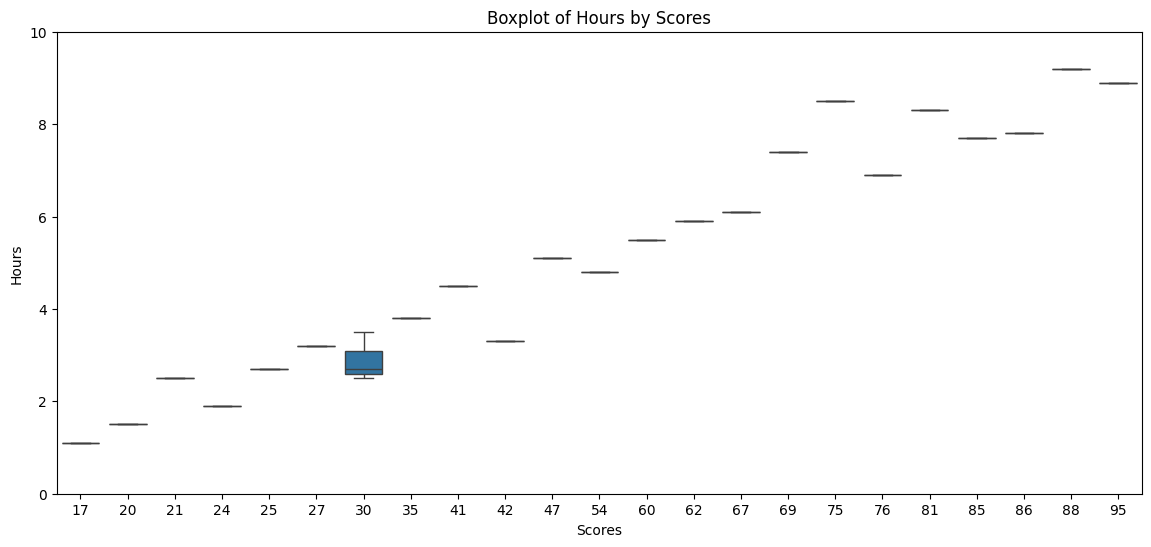

In [38]:
var = 'Scores' # X-axis variable
var2 = 'Hours' # Y-axis variable
f, ax = plt.subplots(figsize=(14, 6))
fig = sns.boxplot(x=var, y=var2, data=data)
fig.axis(ymin=0, ymax=10); # Adjust y-axis limit to a reasonable range for 'Hours'
plt.xlabel(var)
plt.ylabel(var2)
plt.title(f'Boxplot of {var2} by {var}')

In [41]:
X = data[['Hours']].values # Feature(s)
y = data['Scores'].values # Target

In [42]:
data[['Hours']].dtypes

,0
Hours,float64


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2)

In [44]:
adaboost=AdaBoostRegressor(n_estimators=50, learning_rate=0.2,loss='exponential').fit(X_train, y_train)
predict = adaboost.predict(X_test)
r2score = r2_score(predict,y_test)

In [45]:
# Calculating R2 Score
r2score

0.9523787854656321

In [46]:
# Calculating Mean Sqaured Error & Root Mean Squared Error
mse = mean_squared_error(y_test, predict)

rmse = math.sqrt(mse)

print(rmse)

4.822401430361802
